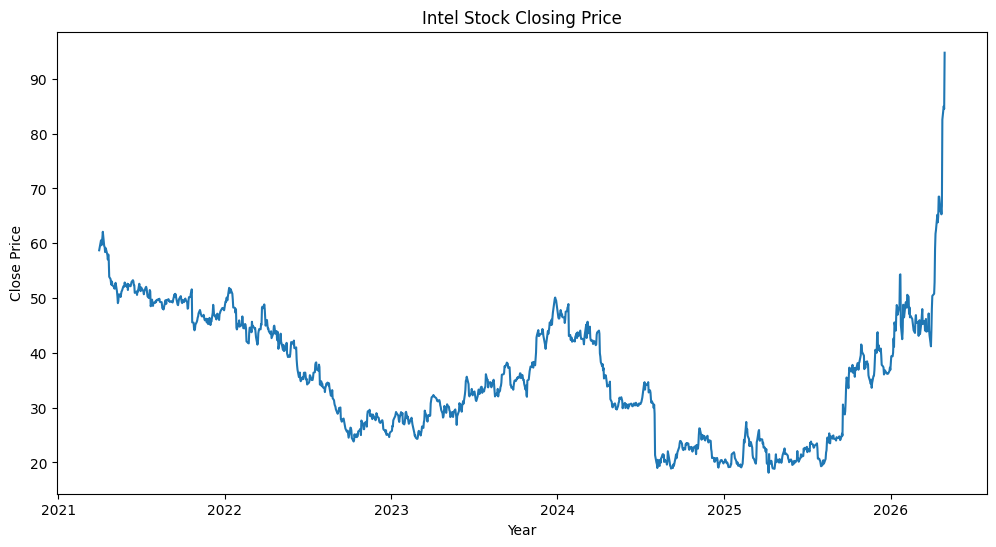

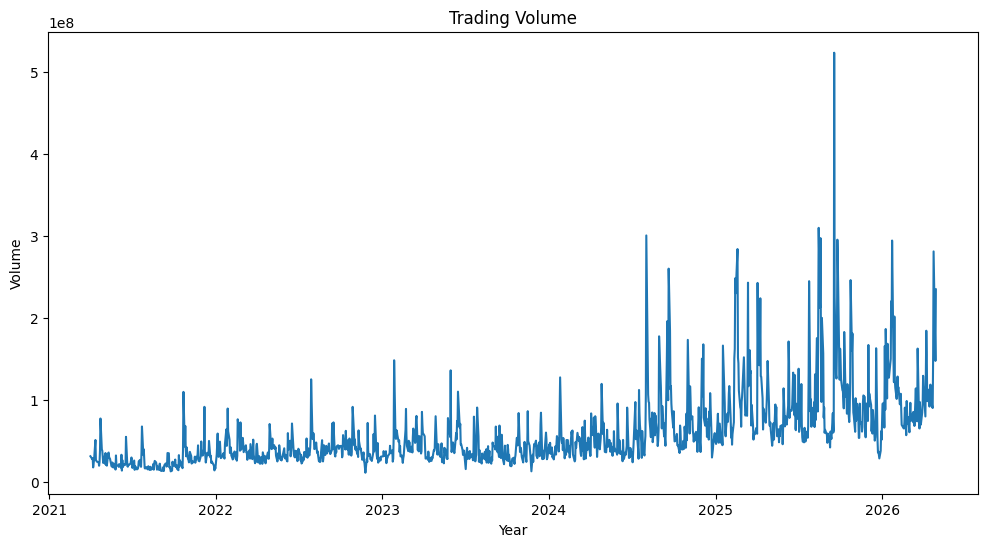

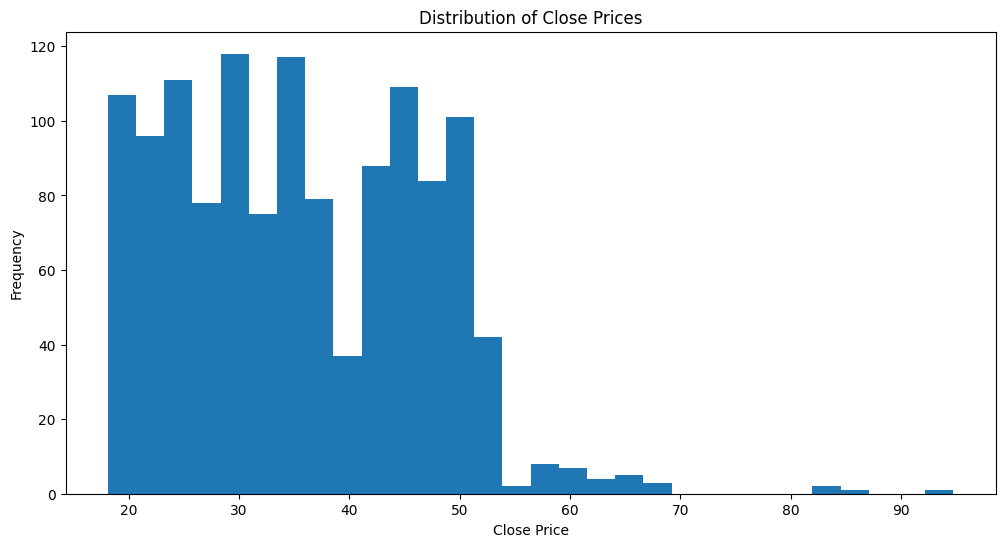

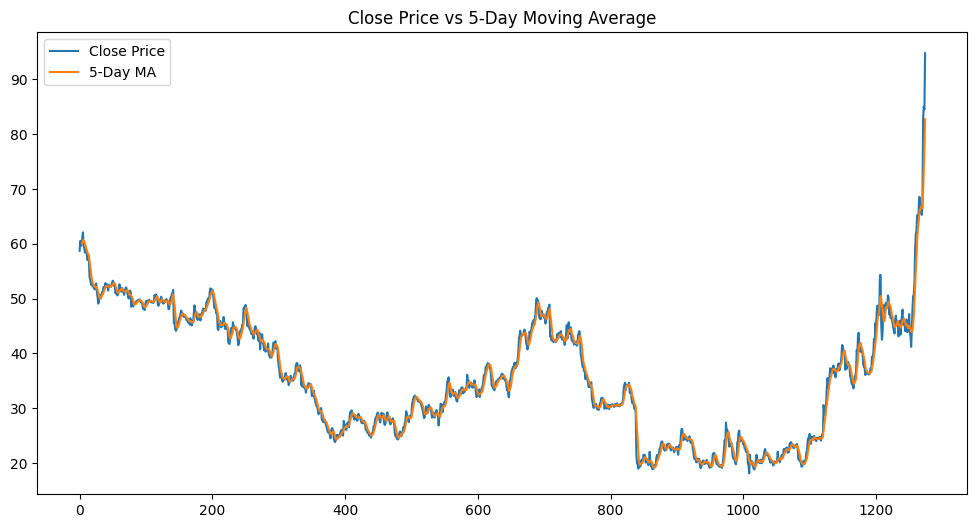

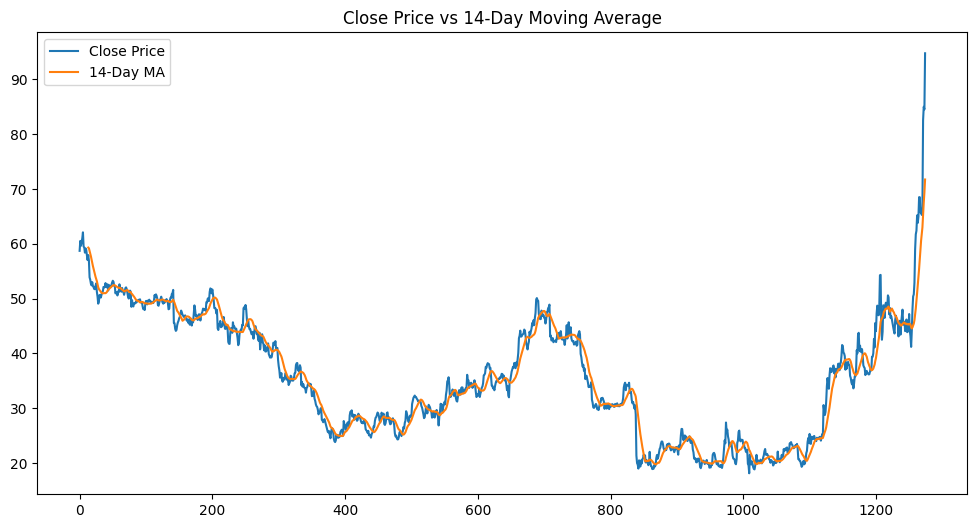

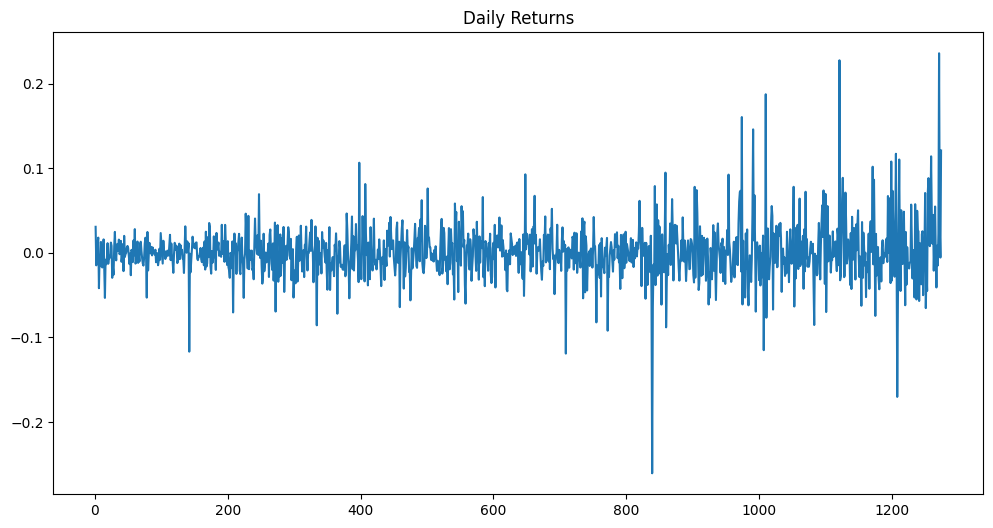

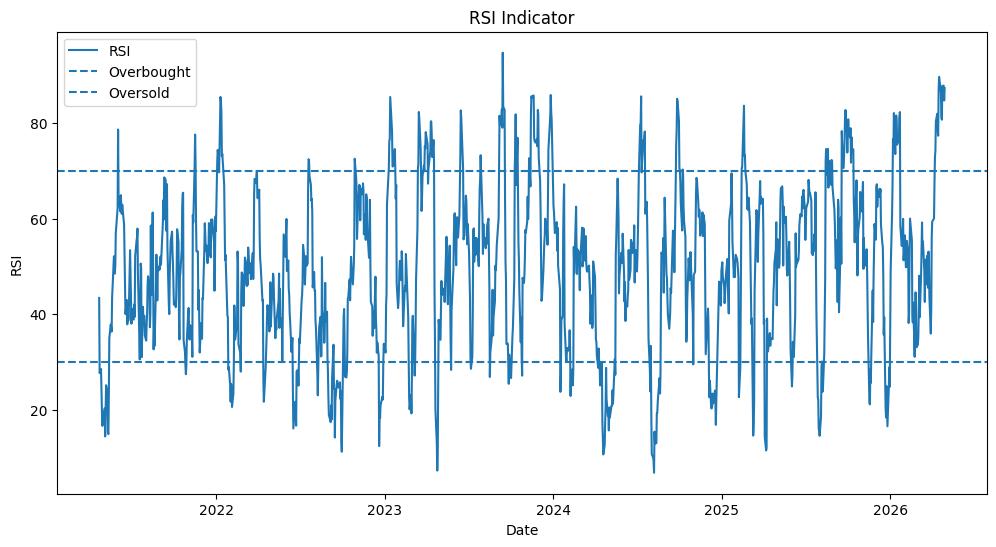

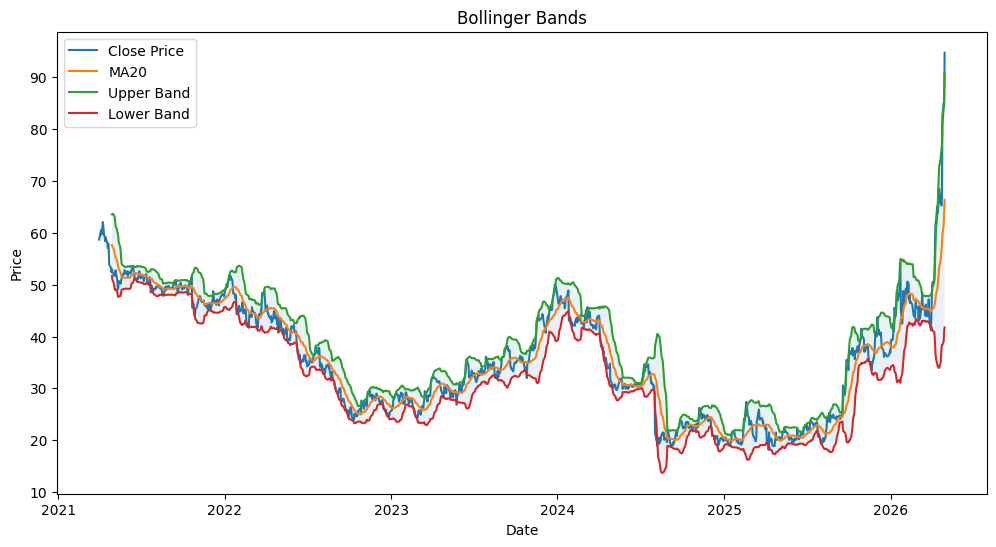

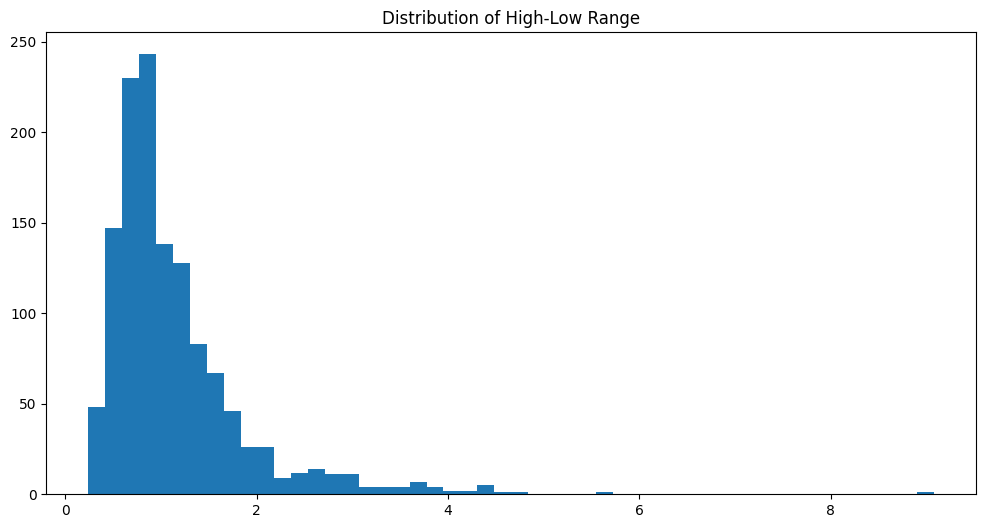

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\cleaned\intel-daily-stock-price-data-cleaned.csv"
)

# Intel Daily Stock Price From 2021-2026
df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"])
plt.title("Intel Stock Closing Price")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()

# Trading Volume
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Volume"])
plt.title("Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()

# Distribution of Close Prices
plt.figure(figsize=(12,6))
plt.hist(df["Close"], bins=30)
plt.title("Distribution of Close Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

# 5-Days Moving Average
df["MA5"] = df["Close"].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["MA5"], label="5-Day MA")
plt.title("Close Price vs 5-Day Moving Average")
plt.legend()
plt.show()

# 14-Days Moving Average
df["MA14"] = df["Close"].rolling(window=14).mean()

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["MA14"], label="14-Day MA")
plt.title("Close Price vs 14-Day Moving Average")
plt.legend()
plt.show()

# Daily Return
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Daily_Return"])
plt.title("Daily Returns")
plt.show()

# RSI Indicator
# Price changes
delta = df['Close'].diff()

# Gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Average gain/loss
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

# Relative strength
rs = avg_gain / avg_loss

# RSI
df['RSI'] = 100 - (100 / (1 + rs))

# Plot
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df['RSI'], label='RSI')

# Overbought/Oversold lines
plt.axhline(70, linestyle='--', label='Overbought')
plt.axhline(30, linestyle='--', label='Oversold')
plt.title('RSI Indicator')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

# Bollinger Bands
# 20-Days Moving Average
df['MA20'] = df['Close'].rolling(window=20).mean()

# Standard deviation
df['STD20'] = df['Close'].rolling(window=20).std()

# Upper and lower bands
df['Upper'] = df['MA20'] + (2 * df['STD20'])
df['Lower'] = df['MA20'] - (2 * df['STD20'])

# Plot
plt.figure(figsize=(12,6))

# Price
plt.plot(df["Date"], df['Close'], label='Close Price')

# Bands
plt.plot(df["Date"], df['MA20'], label='MA20')
plt.plot(df["Date"], df['Upper'], label='Upper Band')
plt.plot(df["Date"], df['Lower'], label='Lower Band')

# Fill between bands
plt.fill_between(
    df["Date"],
    df['Upper'],
    df['Lower'],
    alpha=0.1
)

plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# High-Low Range
df['HL_Range'] = df['High'] - df['Low']

plt.figure(figsize=(12,6))
plt.hist(df['HL_Range'], bins=50)
plt.title('Distribution of High-Low Range')
plt.show()